In [2]:
import numpy as np
import torch
import physicsnemo
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch.nn.functional as F
from typing import cast
from matplotlib.axes import Axes
from utils import CustomDataset
from physicsnemo.sym.eq.phy_informer import PhysicsInformer
from diffusion_eq import Diffusion
import pathlib
from omegaconf import DictConfig, OmegaConf
from utils import darcy_mask1, corr_indicator

torch.manual_seed(0)
np.random.seed(0)

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [4]:
from test_inverse_darcy import load_model_dir
test_dataset_path = "datasets/Darcy_241/piececonst_r241_N1024_test.hdf5"

fno_model_dir = "seeded_runs_darcy/fno_no_physics_seed_0"
fno_cfg, fno_model_path, fno_model_dir = load_model_dir(fno_model_dir)

pino_model_dir = "seeded_runs_darcy/fno_no_scaling_seed_0"
pino_cfg, pino_model_path, pino_model_dir = load_model_dir(pino_model_dir)

physics_only_model_dir = "./inverse_darcy_training/physics_only_seed_1"
physics_only_cfg, physics_only_model_path, physics_only_model_dir = load_model_dir(physics_only_model_dir)

noisy_fno_model_dir = "seeded_runs_darcy/noisy_fno_seed_0"
noisy_fno_cfg, noisy_fno_model_path, noisy_fno_model_dir = load_model_dir(noisy_fno_model_dir)


In [5]:
def instantiate_model(path):
    model = physicsnemo.Module.from_checkpoint(str(path)).to(device)
    model.eval()
    return model

dataset_path = pathlib.Path(test_dataset_path).resolve()
resolution = 241
assert pino_cfg.mappings == fno_cfg.mappings, "Mappings must be the same for both models"
mappings_dict = OmegaConf.to_container(pino_cfg.mappings, resolve=True)
dataset = CustomDataset(dataset_path, device=device, mappings=mappings_dict, res=resolution)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

forcing_fn = 1.0
permeability_min = 3.0
permeability_max = 12.0
def run_inference(u, model, cfg):
    with torch.inference_mode():
        u_input = u / cfg.scaling.darcy

        out_raw = model(u_input)

        return darcy_mask1(out_raw, permeability_min, permeability_max)
    
# Use Diffusion equation for the Darcy PDE
fd_dx = 1.0 / float(resolution - 1)
darcy = Diffusion(T="u", time=False, dim=2, D="k", Q=forcing_fn)
phy_informer = PhysicsInformer(
    required_outputs=["diffusion_u"],
    equations=darcy,
    grad_method="finite_difference",
    device=str(device),
    fd_dx=fd_dx,
)

selected key: Kcoeff, mean: 7.50497e+00, std: 4.35349e+00, max: 1.20000e+01, min: 3.00000e+00
selected key: Kcoeff_x, mean: -9.04197e-02, std: 2.45866e+01, max: 1.47419e+02, min: -1.47419e+02
selected key: Kcoeff_y, mean: 1.48573e-01, std: 2.46997e+01, max: 1.47419e+02, min: -1.47419e+02
selected key: coeff, mean: 7.50497e+00, std: 4.50000e+00, max: 1.20000e+01, min: 3.00000e+00
selected key: sol, mean: 5.72228e-03, std: 3.87210e-03, max: 1.83194e-02, min: 1.00835e-06


In [ ]:
fno_model = instantiate_model(fno_model_path)
pino_model = instantiate_model(pino_model_path)
physics_only_model = instantiate_model(physics_only_model_path)

Warp CUDA warning: Could not find or load the NVIDIA CUDA driver. Proceeding in CPU-only mode.


Warp DeprecationWarning: The namespace `warp.context` will soon be removed from the public API. It can still be accessed from `warp._src.context` but might be changed or removed without notice.
Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.


/scratch/cwilczewski/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'data' is not defined

In [ ]:
k_pred_fno = run_inference(u, fno_model, fno_cfg)
k_pred_pino = run_inference(u, pino_model, pino_cfg)
k_pred_po = run_inference(u, physics_only_model, physics_only_cfg)

fig, axes = cast(tuple, plt.subplots(1, 5, figsize=(25, 4.5)))
im0 = axes[1].imshow(k.squeeze().cpu().numpy(), cmap='viridis', vmin=permeability_min, vmax=permeability_max)
axes[1].set_title('Ground Truth')
plt.colorbar(im0, ax=axes[1])

im1 = axes[2].imshow(k_pred_fno.squeeze().cpu().numpy(), cmap='viridis', vmin=permeability_min, vmax=permeability_max)
axes[2].set_title('FNO Prediction')
plt.colorbar(im1, ax=axes[2])

im_input = axes[0].imshow(u.squeeze().cpu().numpy(), cmap='viridis')
axes[0].set_title('Input Darcy')
plt.colorbar(im_input, ax=axes[0])

im2 = axes[3].imshow(k_pred_pino.squeeze().cpu().numpy(), cmap='viridis', vmin=permeability_min, vmax=permeability_max)
axes[3].set_title('PINO Prediction')
plt.colorbar(im2, ax=axes[3])

im3 = axes[4].imshow(k_pred_po.squeeze().cpu().numpy(), cmap='viridis', vmin=permeability_min, vmax=permeability_max)
axes[4].set_title('Physics-Only Prediction')
plt.colorbar(im3, ax=axes[4])

plt.tight_layout()
plt.show()

In [50]:
# fno_model = instantiate_model(fno_model_path)
noisy_fno_model = instantiate_model(noisy_fno_model_path)
data = next(iter(dataloader))
k = data["permeability"]
u = data["darcy"]
k_pred_fno = run_inference(u, fno_model, fno_cfg)
k_pred_noisy_fno = run_inference(u, noisy_fno_model, noisy_fno_cfg)

NameError: name 'k_pred_fno' is not defined

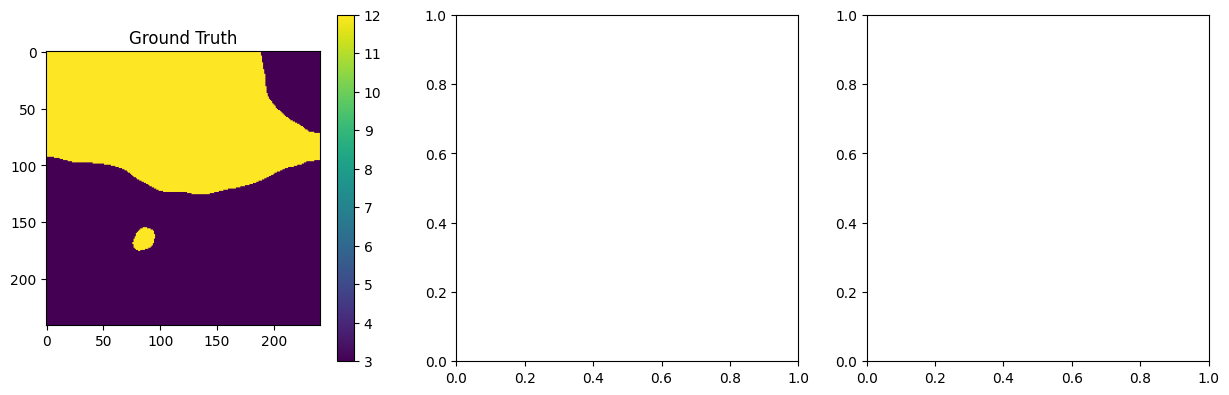

In [48]:
fig, axes = cast(tuple, plt.subplots(1, 3, figsize=(15, 4.5)))
im0 = axes[0].imshow(k.squeeze().cpu().numpy(), cmap='viridis', vmin=permeability_min, vmax=permeability_max)
axes[0].set_title('Ground Truth')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(k_pred_fno.squeeze().cpu().numpy(), cmap='viridis', vmin=permeability_min, vmax=permeability_max)
axes[1].set_title('FNO Prediction')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(k_pred_noisy_fno.squeeze().cpu().numpy(), cmap='viridis', vmin=permeability_min, vmax=permeability_max)
axes[2].set_title('Noisy FNO Prediction')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

In [1]:
alpha = 0.2
loader = iter(dataloader)
_, data = next(loader), next(loader)
k = data["permeability"]
u = data["darcy"]
u_std = u.std(dim=(-2, -1), keepdim=True)
noise = torch.randn_like(u) * u_std * alpha
u_noisy = u + noise

k_pred_fno = run_inference(u_noisy, fno_model, fno_cfg)
k_pred_pino = run_inference(u_noisy, pino_model, pino_cfg)
k_pred_noisy_fno = run_inference(u_noisy, noisy_fno_model, noisy_fno_cfg)

NameError: name 'dataloader' is not defined

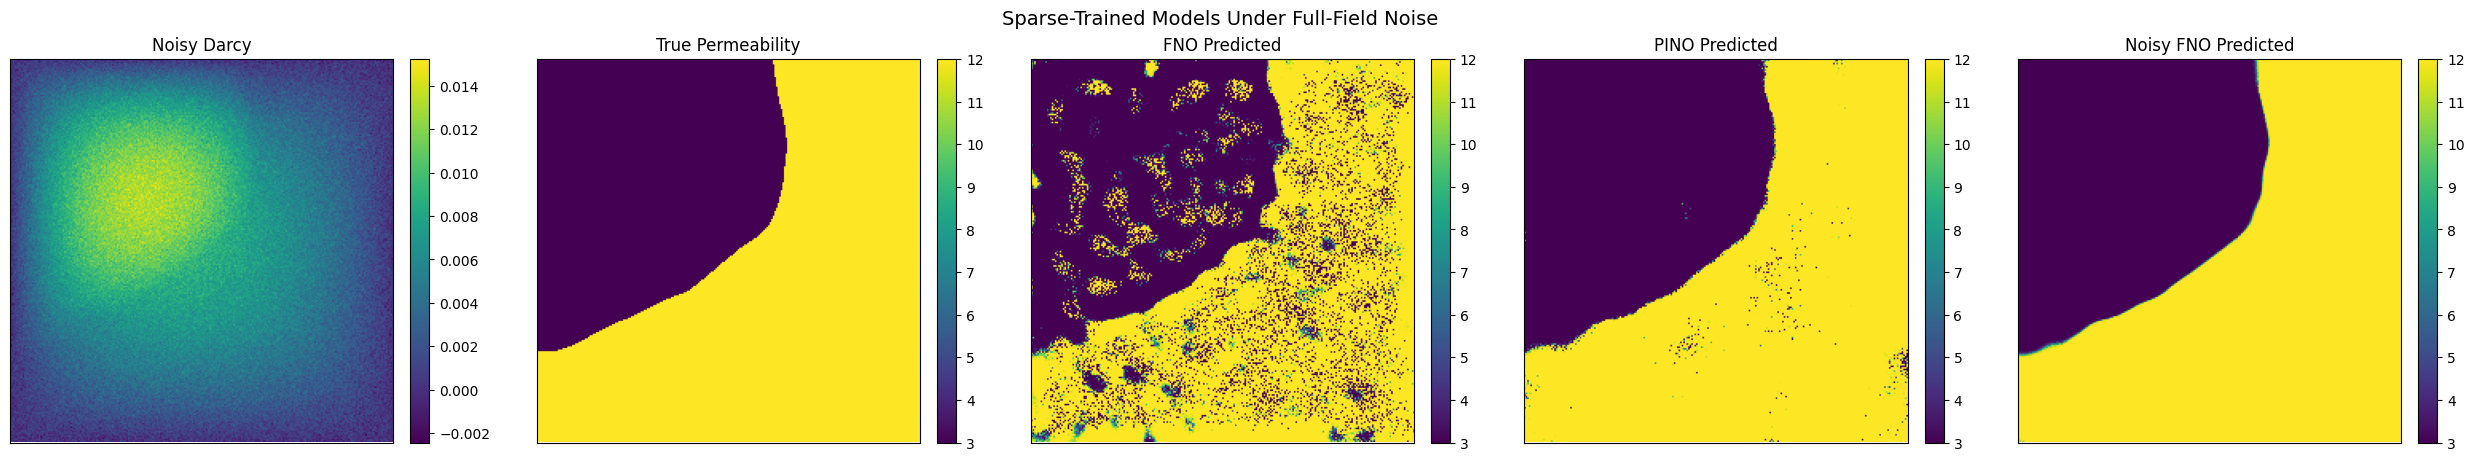

In [56]:
fig2, ax2 = plt.subplots(
    1,
    5,
    figsize=(25, 4.5),
    squeeze=False,
     constrained_layout=True,
)
fig2.suptitle(
    f"Sparse-Trained Models Under Full-Field Noise",
    fontsize=14,
)

plot_with_colorbar(fig2, ax2,0,0,u_noisy.cpu().numpy() ,"Noisy Darcy",cmap="viridis",)
plot_with_colorbar(fig2, ax2,1,0,k.cpu().numpy(),"True Permeability",cmap="viridis",)
plot_with_colorbar(fig2, ax2,2,0,k_pred_fno.cpu().numpy(),"FNO Predicted",cmap="viridis",)
plot_with_colorbar(fig2, ax2,3,0,k_pred_pino.cpu().numpy(),"PINO Predicted",cmap="viridis",)
plot_with_colorbar(fig2, ax2,4,0,k_pred_noisy_fno.cpu().numpy(),"Noisy FNO Predicted",cmap="viridis",)

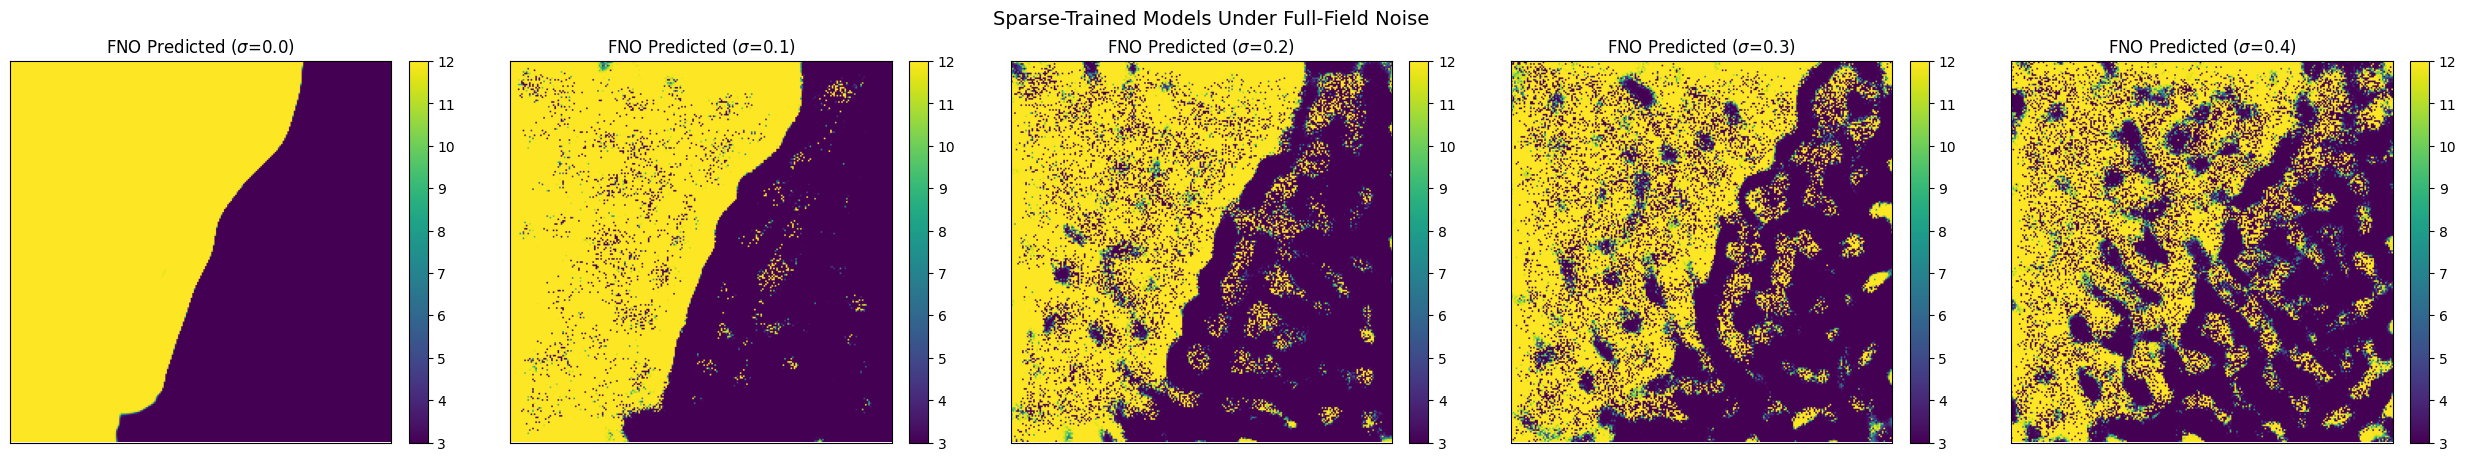

In [ ]:
fig2, ax2 = plt.subplots(
    1,
    5,
    figsize=(25, 4.5),
    squeeze=False,
     constrained_layout=True,
)
fig2.suptitle(
    f"FNO Under Full-Field Noise",
    fontsize=14,
)

alphas = [0.0, 0.1, 0.2, 0.3, 0.4]
loader = iter(dataloader)
_, _, data = next(loader), next(loader), next(loader)
k = data["permeability"]
u = data["darcy"]
u_std = u.std(dim=(-2, -1), keepdim=True)
for i, alpha in enumerate(alphas):
    noise = torch.randn_like(u) * u_std * alpha
    u_noisy = u + noise
    k_pred_fno = run_inference(u_noisy, fno_model, fno_cfg)
    plot_with_colorbar(
        fig2,
        ax2,
        i,
        0,
        k_pred_fno.cpu().numpy(),
        f"FNO Predicted ($\\sigma$={alpha})",
        cmap="viridis",
    )

In [34]:
sparse_pino_model_dir = "neural_operator_outputs/sparse/pino_0"
sparse_pino_cfg, sparse_pino_model_path, sparse_pino_model_dir = load_model_dir(sparse_pino_model_dir)

sparse_fno_model_dir = "neural_operator_outputs/sparse/fno_1"
sparse_fno_cfg, sparse_fno_model_path, sparse_fno_model_dir = load_model_dir(sparse_fno_model_dir)

sparse_pino_weight_1_0_dir = "neural_operator_outputs/sparse/pino_weight_1.0_0"
sparse_1_0_cfg, sparse_1_0_path, sparse_1_0_dir = load_model_dir(sparse_pino_weight_1_0_dir)

sparse_pino_model = instantiate_model(sparse_pino_model_path)
sparse_fno_model = instantiate_model(sparse_fno_model_path)
sparse_weight_1_0_model = instantiate_model(sparse_1_0_path)

In [14]:
from utils import make_random_mask
def run_inference_sparse(u, model, scaling: float, mask, p_min=permeability_min, p_max=permeability_max):
    with torch.inference_mode():
        u_masked = mask * u
        model_input = torch.cat([u_masked / scaling, mask], dim=1)
        out_raw = model(model_input)
        return darcy_mask1(out_raw, p_min, p_max)
    
def plot_with_colorbar(
    fig,
    ax,
    col,
    row,
    data,
    title,
    *,
    cmap="viridis",
    vmin=None,
    vmax=None,
    sensor_mask=None,
    draw_sensor_circles=False,
):
    image = np.squeeze(data)
    axis = cast(Axes, ax[row, col])
    im = axis.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax)

    if draw_sensor_circles and sensor_mask is not None:
        mask_np = np.squeeze(sensor_mask)
        ys, xs = np.where(mask_np > 0.5)

        axis.scatter(
            xs,
            ys,
            s=45,
            facecolors="none",
            edgecolors="white",
            linewidths=0.8,
        )

    axis.set_title(title, fontsize=12)
    axis.set_xticks([])
    axis.set_yticks([])
    fig.colorbar(im, ax=axis, fraction=0.046, pad=0.04)

In [15]:
sensor_density = 0.1
data = next(iter(dataloader))
u = data["darcy"]
k = data["permeability"]
mask = make_random_mask(u, sensor_density)
print(type(mask))
k_pred_sparse_pino = run_inference_sparse(u, sparse_pino_model, sparse_pino_cfg.scaling.darcy, mask)
k_pred_sparse_fno = run_inference_sparse(u, sparse_fno_model, sparse_fno_cfg.scaling.darcy, mask)
k_pred_sparse_weight_1_0 = run_inference_sparse(u, sparse_weight_1_0_model, sparse_1_0_cfg.scaling.darcy, mask)

<class 'torch.Tensor'>


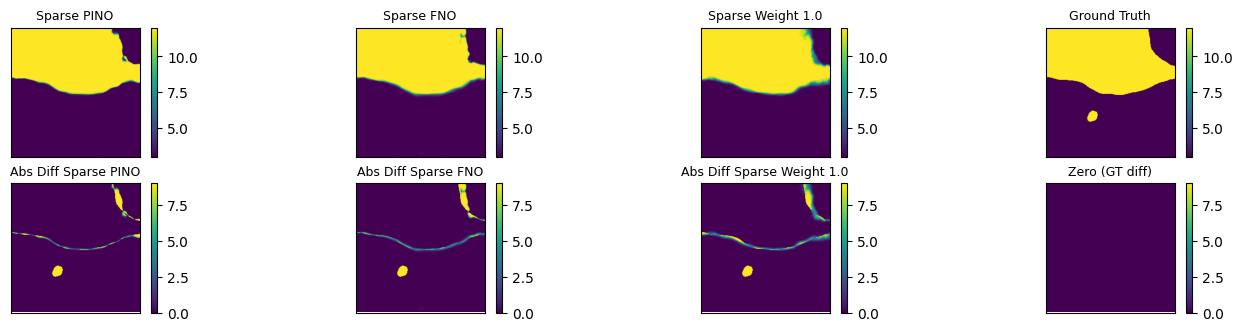

In [40]:
k = data["permeability"]
fig1, ax1 = plt.subplots(
    2,
    4,
    figsize=(3 * 4.6, 1 * 3.2),
    squeeze=False,
    constrained_layout=True,
)

plot_with_colorbar(fig1, ax1,0,0,k_pred_sparse_pino,"Sparse PINO",cmap="viridis",)
plot_with_colorbar(fig1, ax1,1,0,k_pred_sparse_fno,"Sparse FNO",cmap="viridis",)
plot_with_colorbar(fig1, ax1,2,0,k_pred_sparse_weight_1_0,"Sparse Weight 1.0",cmap="viridis",)
plot_with_colorbar(fig1, ax1,3,0,k,"Ground Truth",cmap="viridis",)
diff_pino = np.abs(k_pred_sparse_pino.cpu().numpy() - k.cpu().numpy())
diff_fno = np.abs(k_pred_sparse_fno.cpu().numpy() - k.cpu().numpy())
diff_w1 = np.abs(k_pred_sparse_weight_1_0.cpu().numpy() - k.cpu().numpy())
vmax = float(max(diff_pino.max(), diff_fno.max(), diff_w1.max()))

plot_with_colorbar(fig1, ax1, 0, 1, diff_pino, "Abs Diff Sparse PINO", cmap="viridis", vmin=0, vmax=vmax)
plot_with_colorbar(fig1, ax1, 1, 1, diff_fno, "Abs Diff Sparse FNO", cmap="viridis", vmin=0, vmax=vmax)
plot_with_colorbar(fig1, ax1, 2, 1, diff_w1, "Abs Diff Sparse Weight 1.0", cmap="viridis", vmin=0, vmax=vmax)
plot_with_colorbar(fig1, ax1, 3, 1, np.zeros_like(k.cpu().numpy()), "Zero (GT diff)", cmap="viridis", vmin=0, vmax=vmax)

In [37]:
sensor_density = 1.0
alpha = 1.0
data = next(iter(dataloader))
u = data["darcy"]
k = data["permeability"]
mask = make_random_mask(u, sensor_density)

u_std = u.std(dim=(-2, -1), keepdim=True)
noise = torch.randn_like(u) * u_std * alpha
u_noisy = u + noise

k_pred_sparse_pino = run_inference_sparse(u_noisy, sparse_pino_model, sparse_pino_cfg.scaling.darcy, mask)
k_pred_sparse_fno = run_inference_sparse(u_noisy, sparse_fno_model, sparse_fno_cfg.scaling.darcy, mask)
k_pred_weight1_0 = run_inference_sparse(u_noisy, sparse_weight_1_0_model, sparse_1_0_cfg.scaling.darcy, mask)

u_masked = mask * u_noisy
fno_pred = run_inference(u_masked, fno_model, fno_cfg)
pino_pred = run_inference(u_masked, pino_model, pino_cfg)

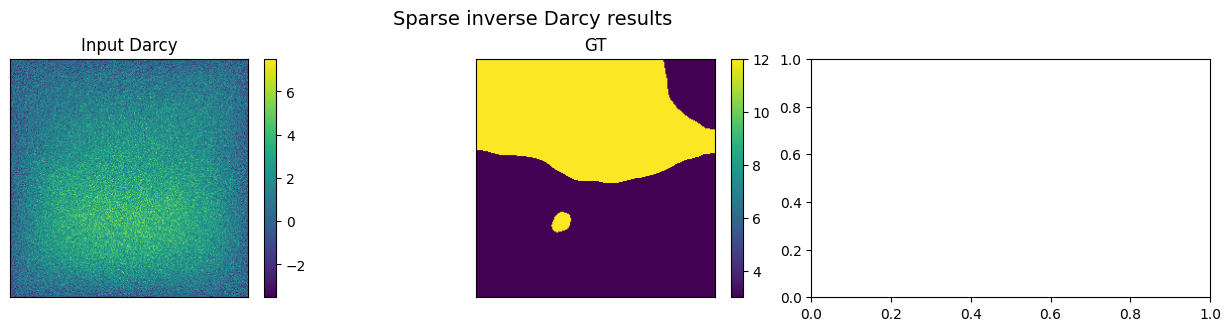

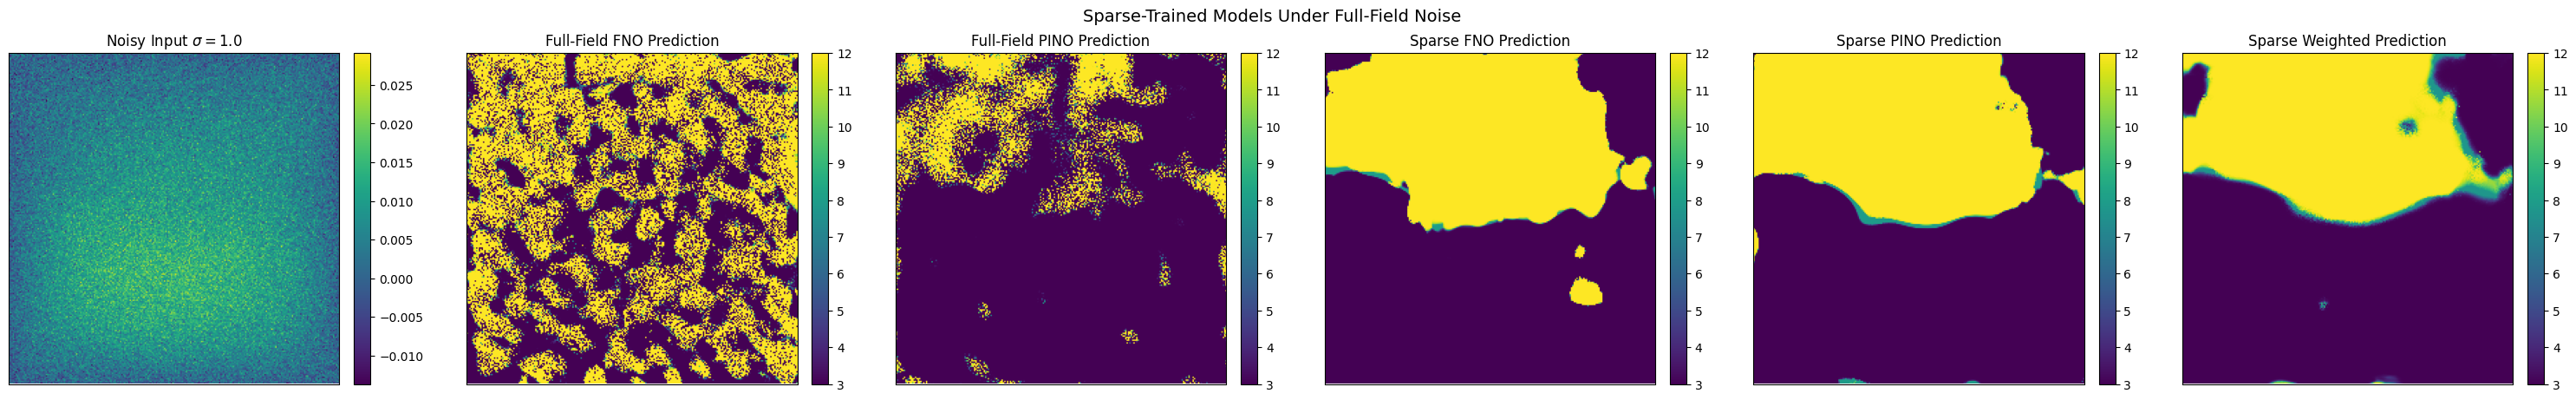

In [38]:
fig1, ax1 = plt.subplots(
    1,
    3,
    figsize=(3 * 4.6, 1 * 3.2),
    squeeze=False,
    constrained_layout=True,
)

fig1.suptitle(
    f"Sparse inverse Darcy results ",
    fontsize=14,
)

fig2, ax2 = plt.subplots(
    1,
    6,
    figsize=(30, 4.5),
    squeeze=False,
     constrained_layout=True,
)
fig2.suptitle(
    f"Sparse-Trained Models Under Full-Field Noise",
    fontsize=14,
)

plot_with_colorbar(fig1, ax1,0,0,u_masked.cpu().numpy() / fno_cfg.scaling.darcy,"Input Darcy",cmap="viridis",)
plot_with_colorbar(fig1, ax1,1,0,k,"GT",cmap="viridis")

# plot_with_colorbar(fig2, ax2,1,0,k.cpu().numpy(),"Ground Truth Permeability",cmap="viridis",vmin=permeability_min,vmax=permeability_max,)
plot_with_colorbar(fig2, ax2,1,0,fno_pred.cpu().numpy(),"Full-Field FNO Prediction",cmap="viridis",vmin=permeability_min,vmax=permeability_max,)
plot_with_colorbar(fig2, ax2,2,0,pino_pred.cpu().numpy(),"Full-Field PINO Prediction",cmap="viridis",vmin=permeability_min,vmax=permeability_max,)
plot_with_colorbar(fig2, ax2,3,0,k_pred_sparse_fno.cpu().numpy(),"Sparse FNO Prediction",cmap="viridis",vmin=permeability_min,vmax=permeability_max,)
plot_with_colorbar(fig2, ax2,4,0,k_pred_sparse_pino.cpu().numpy(),"Sparse PINO Prediction",cmap="viridis",vmin=permeability_min,vmax=permeability_max,)
plot_with_colorbar(fig2, ax2,5,0,k_pred_weight1_0.cpu().numpy(),"Sparse Weighted Prediction",cmap="viridis",vmin=permeability_min,vmax=permeability_max,)
plot_with_colorbar(fig2, ax2,0,0,u_masked.cpu().numpy(),"Noisy Input $\sigma = 1.0$",cmap="viridis")

The sparse observation analysis is somwhat weaker i believe. the claim that "model relies on training distribution as a prior" could be true but i don't think its directly proven. Maybe you could do an expeirment (outside teh training distribution)

In [12]:
pdebench_path = "datasets/PDEBench/2D_DarcyFlow_beta1.0_test_split.hdf5" 
mappings = {
    "darcy": "tensor",
    "permeability": "nu",
}
pdebench_dataset = CustomDataset(pdebench_path, device=device, mappings=mappings, res=128)
pdebench_dataloader = DataLoader(pdebench_dataset, batch_size=1, shuffle=False)

selected key: nu, mean: 5.49678e-01, std: 4.50000e-01, max: 1.00000e+00, min: 1.00000e-01
selected key: tensor, mean: 1.58443e-01, std: 1.38413e-01, max: 1.22250e+00, min: 1.79977e-04
selected key: x-coordinate, mean: 5.00000e-01, std: 2.88666e-01, max: 9.96094e-01, min: 3.90625e-03
selected key: y-coordinate, mean: 5.00000e-01, std: 2.88666e-01, max: 9.96094e-01, min: 3.90625e-03


In [ ]:
u_scaling = 1.38413e-01
u_mean = 1.58443e-01
iter_data = iter(pdebench_dataloader)
data = next(iter_data)
data = next(iter_data)
k = data["permeability"]
u = data["darcy"]
print(sparse_pino_cfg.scaling.darcy)
print(sparse_fno_cfg.scaling.darcy)
print(sparse_1_0_cfg.scaling.darcy)
sensor_density = 0.3
mask = make_random_mask(u, sensor_density)
u_masked = mask * u
k_pred = run_inference_sparse(u_masked, sparse_fno_model, 3.87210e-03, mask, p_min=0.1, p_max=1.0)
k_pred_pino = run_inference_sparse(u_masked, sparse_pino_model, 3.87210e-03, mask, p_min=0.1, p_max=1.0)

tensor(0.0821)
0.00388433
0.00388433
0.00388433


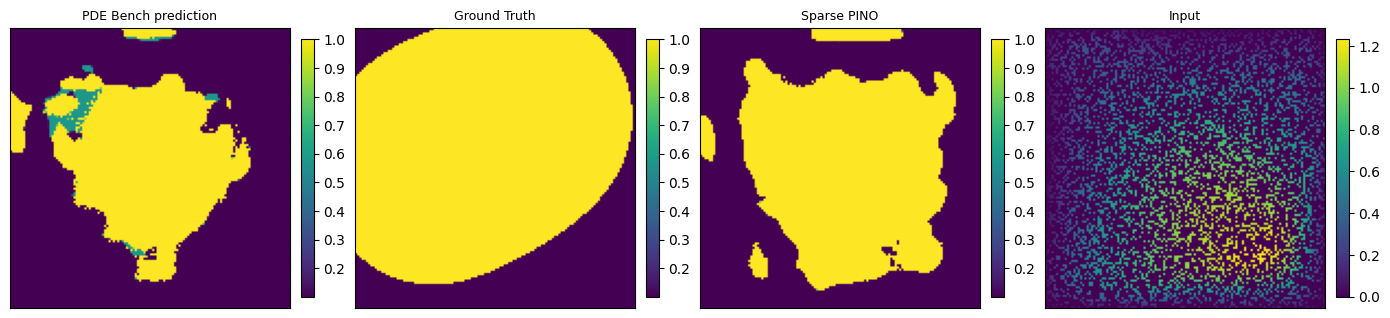

In [26]:
fig1, ax1 = plt.subplots(
    1,
    4,
    figsize=(3 * 4.6, 1 * 3.2),
    squeeze=False,
    constrained_layout=True,
)


plot_with_colorbar(fig1, ax1,0,0,k_pred,"PDE Bench prediction",cmap="viridis",)
plot_with_colorbar(fig1, ax1,1,0,k,"Ground Truth",cmap="viridis",)
plot_with_colorbar(fig1, ax1,2,0,k_pred_pino,"Sparse PINO",cmap="viridis",)
plot_with_colorbar(fig1, ax1,3,0,u_masked/u_scaling,"Input",cmap="viridis",)